# Contents

## 1. Importing libraries and data

## 2. Cleaning Data

Checking missing values

Check for duplicates

Looking for extreme values

## 3. Data prep for regression analysis

Creating a simpler subset

Pair plot

Hypothesis

Scatterplot

Creating NumPy arrays

Split data to training and test

Create regression object and fit to training data

Further cleaning to remove NaN values

## 4. Restart the regression analysis

Scatterplot

NumPy Arrays, training and test set, regression object, fir training set to regression object

Make and plot prediction

Regression statistics

Commentary

## 5. Second Hypothesis

Data prep

New regression analysis

Commentary

## 6. Thoughts on data bias

## 1. Importing libraries and data

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import os
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# This option ensures that the graphs you create are displayed within the notebook without the need to "call" them specifically.

%matplotlib inline

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
path = '/content/drive/MyDrive'

In [6]:
df = pd.read_csv(os.path.join(path,'test_Matches_Data_Clean_Post 1900.csv'))

## 2. Cleaning Data

This data has already been cleaned, but it is good practice to ensure it is clean.

In [7]:
df.columns

Index(['Match ID', 'Match Name', 'Start Date', 'End Date', 'Team 1',
       'Innings 1 Team 1 Runs', 'Innings 1 Team 1 Wickets',
       'Innings 1 Team 1 Extras', 'Innings 2 Team 1 Runs',
       'Innings 2 Team 1 Wickets', 'Innings 2 Team 1 Extras', 'Team 2',
       'Innings 1 Team 2 Runs', 'Innings 1 Team 2 Wickets',
       'Innings 1 Team 2 Extras', 'Innings 2 Team 2 Runs',
       'Innings 2 Team 2 Wickets', 'Innings 2 Team 2 Extras', 'Venue', 'City',
       'Country', 'Toss Winner', 'Toss Winner Choice', 'Winner', 'Result'],
      dtype='object')

In [8]:
df.head()

,Match ID,Match Name,Start Date,End Date,Team 1,Innings 1 Team 1 Runs,Innings 1 Team 1 Wickets,Innings 1 Team 1 Extras,Innings 2 Team 1 Runs,Innings 2 Team 1 Wickets,...,Innings 2 Team 2 Runs,Innings 2 Team 2 Wickets,Innings 2 Team 2 Extras,Venue,City,Country,Toss Winner,Toss Winner Choice,Winner,Result
0,62387,Australia Vs South Africa,27/05/1912,28/05/1912,Australia,448,10,24,NaN,NaN,...,95.0,10.0,9.0,Old Trafford,Manchester,England,Australia,bat,Australia,Australia won by an innings and 88 runs
1,62388,England Vs South Africa,10/06/1912,12/06/1912,South Africa,58,10,17,217.0,10.0,...,NaN,NaN,NaN,Lord's,London,England,South Africa,bat,England,England won by an innings and 62 runs
2,62389,England Vs Australia,24/06/1912,26/06/1912,England,310,7,22,NaN,NaN,...,NaN,NaN,NaN,Lord's,London,England,England,bat,NaN,Match drawn
3,62390,England Vs South Africa,08/07/1912,10/07/1912,England,242,10,14,238.0,10.0,...,159.0,10.0,11.0,Headingley,Leeds,England,England,bat,England,England won by 174 runs
4,62391,Australia Vs South Africa,15/07/1912,17/07/1912,South Africa,263,10,29,173.0,10.0,...,48.0,0.0,1.0,Lord's,London,England,South Africa,bat,Australia,Australia won by 10 wickets


In [9]:
df.shape

(2473, 25)

### Checking missing values

In [10]:
# Check for missing values

df.isnull().sum()

# No missing values to handle

,0
Match ID,0
Match Name,0
Start Date,0
End Date,0
Team 1,0
Innings 1 Team 1 Runs,0
Innings 1 Team 1 Wickets,0
Innings 1 Team 1 Extras,0
Innings 2 Team 1 Runs,317
Innings 2 Team 1 Wickets,317


In [11]:
#Winner perhaps shouldn't have missing values, so will look at this:

df['Winner'].unique()

array(['Australia', 'England', nan, 'South Africa', 'West Indies',
       'India', 'Pakistan', 'New Zealand', 'Sri Lanka', 'Zimbabwe',
       'Bangladesh', 'Afghanistan', 'Ireland'], dtype=object)

In [12]:
unique_counts = df['Winner'].value_counts()
print(unique_counts)

Winner
Australia       394
England         358
West Indies     183
South Africa    178
India           178
Pakistan        148
New Zealand     115
Sri Lanka       103
Bangladesh       19
Zimbabwe         13
Afghanistan       3
Ireland           1
Name: count, dtype: int64


In [13]:
unique_counts.sum()

np.int64(1693)

In [14]:
#My assumption is that when there is no winner it is beacuse the match is drawn

df_winner_result = df[['Winner','Result']]
display(df_winner_result.head(20))

,Winner,Result
0,Australia,Australia won by an innings and 88 runs
1,England,England won by an innings and 62 runs
2,NaN,Match drawn
3,England,England won by 174 runs
4,Australia,Australia won by 10 wickets
5,NaN,Match drawn
6,NaN,Match drawn
7,England,England won by 10 wickets
8,England,England won by 244 runs
9,England,England won by an innings and 124 runs


In [15]:
# Take df_winner_result, and filter for only Winner == NaN, and see how many unique values there are

df_winner_result[df_winner_result['Winner'].isnull()]['Result'].unique()

array(['Match drawn', 'Match tied'], dtype=object)

#### Only draws or ties, so there is no important missing information, can proceed

### Check for duplicates

In [16]:
#Check for duplicates

dups = df.duplicated()

In [17]:
dups.shape

#No duplicates

(2473,)

Looking for extreme values

/tmp/ipython-input-1573972451.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Innings 1 Team 1 Runs'], bins=25)


<Axes: xlabel='Innings 1 Team 1 Runs', ylabel='Density'>

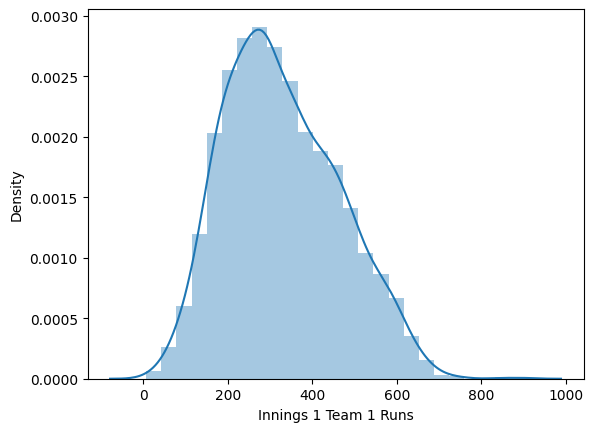

In [18]:
# Will alwsays look at first innings, so check for any extreme value here

sns.distplot(df['Innings 1 Team 1 Runs'], bins=25)



In [19]:
df['Innings 1 Team 1 Runs'].mean()

np.float64(328.96279822078446)

In [20]:
df['Innings 1 Team 1 Runs'].median()

312.0

In [21]:
df['Innings 1 Team 1 Runs'].max()

903

## 3. Data prep for regression analysis

Creating a simpler subset

In [22]:
# Keeping only the needed varibales for a pair plot

df_for_pair = df[['Innings 1 Team 1 Runs', 'Innings 1 Team 2 Runs', 'Innings 2 Team 1 Runs', 'Innings 2 Team 2 Runs']]

Pair plot

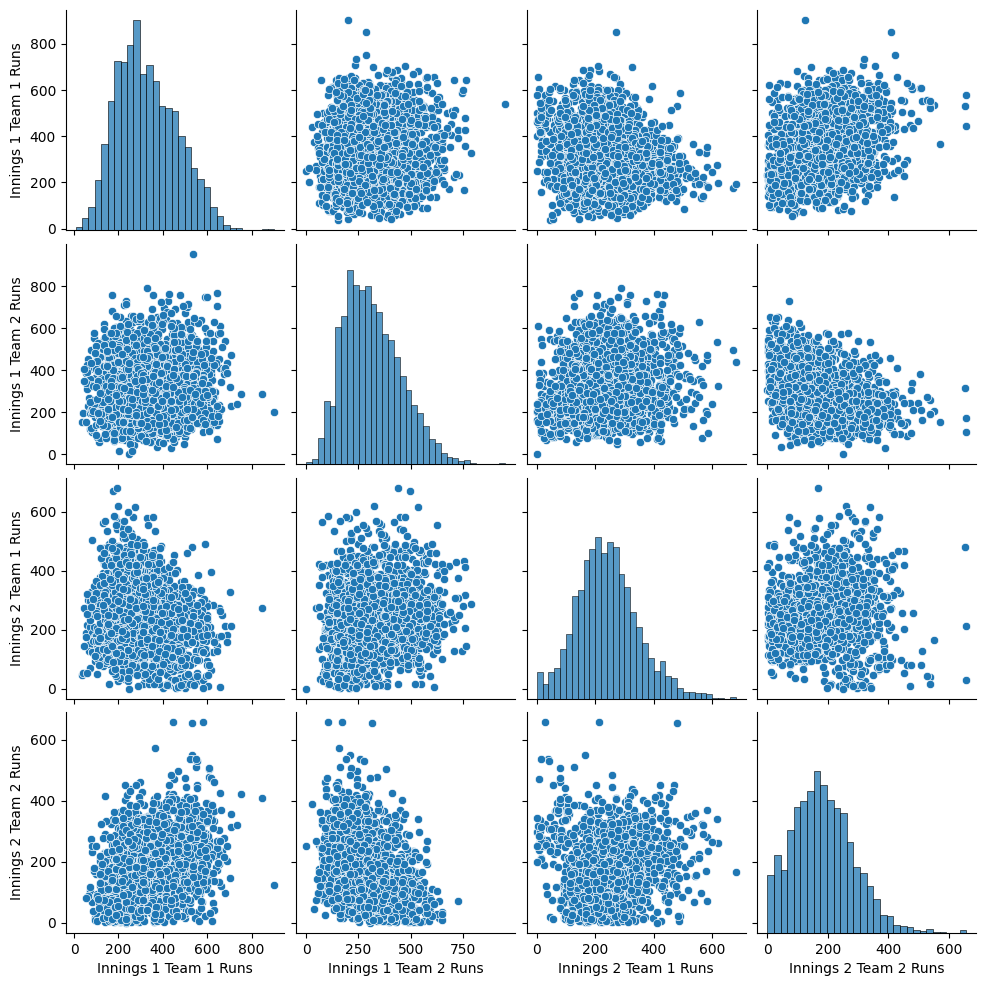

In [23]:
# Create a pair plot

pairplot= sns.pairplot(df_for_pair)

The relationship btween the runs team 2 makes in the first and seond innings looks most interesting, so will investigate this

# Hypothesis
For the team batting second, a higher 1st innings score is a good predictor of a lower 2nd innings score

Scatterplot

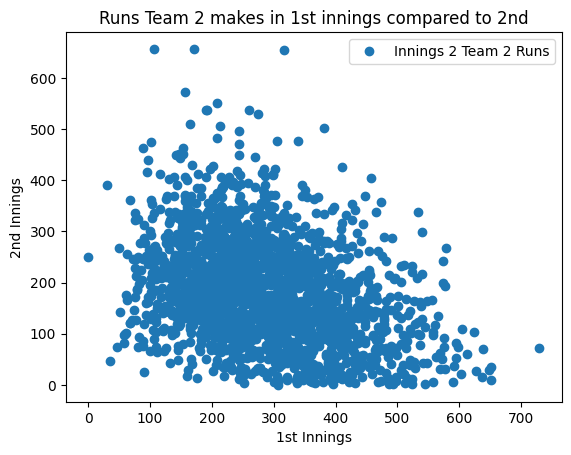

In [24]:
#Start by creating that single scatterplot by itself and well labelled - to investigate, is there a relationship between runs made in 1st innings (x) and runs made in 2nd innings (y)

df.plot(x = 'Innings 1 Team 2 Runs', y='Innings 2 Team 2 Runs',style='o') # The style option creates a scatterplot; without it, we only have lines.
plt.title('Runs Team 2 makes in 1st innings compared to 2nd')
plt.xlabel('1st Innings')
plt.ylabel('2nd Innings')
plt.show()

Creating NumPy arrays

In [25]:
# Reshape the variables into NumPy arrays and put them into separate objects.

X = df['Innings 1 Team 2 Runs'].values.reshape(-1,1)
y = df['Innings 2 Team 2 Runs'].values.reshape(-1,1)

In [26]:
X

array([[265.],
       [337.],
       [282.],
       ...,
       [263.],
       [188.],
       [178.]])

In [27]:
y

array([[ 95.],
       [ nan],
       [ nan],
       ...,
       [111.],
       [182.],
       [318.]])

Split data to training and test

In [28]:
# Split data into a training set and a test set.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

Create regression object and fit to training data

In [29]:
# Create a regression object.

regression = LinearRegression()  # This is the regression object, which will be fit onto the training set.

In [30]:
# Fit the regression object onto the training set.
#' So we have given them the training data - 70% of our dataset - and it can now make predictions in our test data - the other 30%

regression.fit(X_train, y_train)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

There's an issue here, Team 2 doesn't alwasy bat, even in the first innings, so there are NaN Values - I need to drop them before proceeding.

Further cleaning to remove NaN values

In [31]:
# Going to start with a subset, just to make life simpler

df_Team2runs = df[['Innings 1 Team 2 Runs', 'Innings 2 Team 2 Runs']]

In [32]:
df_Team2runs.head()

,Innings 1 Team 2 Runs,Innings 2 Team 2 Runs
0,265.0,95.0
1,337.0,NaN
2,282.0,NaN
3,147.0,159.0
4,390.0,48.0


In [33]:
#Clean up that subset (making changes only to the subset not the orginal df)

df_Team2runs = df_Team2runs[df_Team2runs['Innings 1 Team 2 Runs'].isnull() == False]
df_Team2runs = df_Team2runs[df_Team2runs['Innings 2 Team 2 Runs'].isnull() == False]

In [34]:
# Check for missing values

df_Team2runs.isnull().sum()

# No missing values to handle

,0
Innings 1 Team 2 Runs,0
Innings 2 Team 2 Runs,0


# 4. Restart regression analysis

Scatterplot

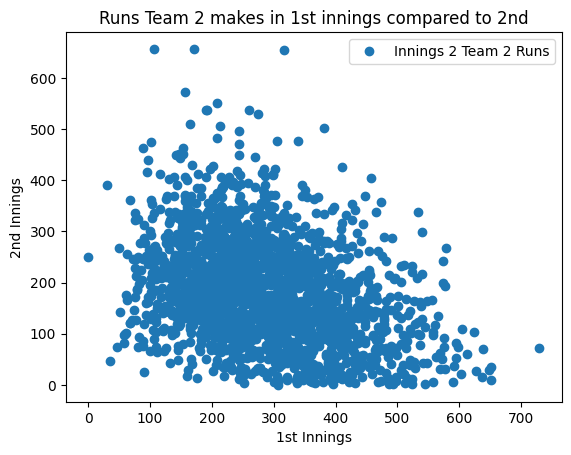

In [35]:
#Start by creating that single scatterplot by itself and well labelled - to investigate, is there a relationship between runs made in 1st innings (x) and runs made in 2nd innings (y)

df_Team2runs.plot(x = 'Innings 1 Team 2 Runs', y='Innings 2 Team 2 Runs',style='o') # The style option creates a scatterplot; without it, we only have lines.
plt.title('Runs Team 2 makes in 1st innings compared to 2nd')
plt.xlabel('1st Innings')
plt.ylabel('2nd Innings')
plt.show()

NumPy Arrays, training and test set, regression object, fir training set to regression object

In [36]:
# Reshape the variables into NumPy arrays and put them into separate objects.

X2 = df_Team2runs['Innings 1 Team 2 Runs'].values.reshape(-1,1)
Y2 = df_Team2runs['Innings 2 Team 2 Runs'].values.reshape(-1,1)

In [37]:
# Split data into a training set and a test set.

X2_train, X2_test, Y2_train, Y2_test = train_test_split(X2, Y2, test_size=0.3, random_state=0)

In [38]:
# Create a regression object.

regression = LinearRegression()  # This is the regression object, which will be fit onto the training set.

In [39]:
# Fit the regression object onto the training set.
#' So we have given them the training data - 70% of our dataset - and it can now make predictions in our test data - the other 30%

regression.fit(X2_train, Y2_train)

LinearRegression()

Make and plot prediction

In [40]:
# Predict the values of y using X.

Y_predicted = regression.predict(X2_test)

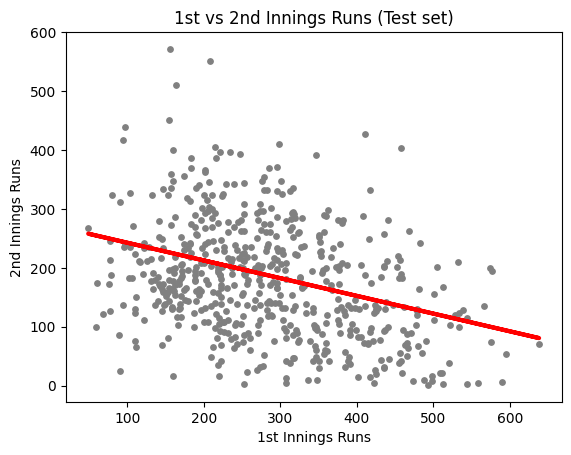

In [41]:
# Create a plot that shows the regression line from the model on the test set.

plot_test = plt
plot_test.scatter(X2_test, Y2_test, color='gray', s = 15)
plot_test.plot(X2_test, Y_predicted, color='red', linewidth =3)
plot_test.title('1st vs 2nd Innings Runs (Test set)')
plot_test.xlabel('1st Innings Runs')
plot_test.ylabel('2nd Innings Runs')
plot_test.show()

Regression statistics

In [43]:
# Create objects that contain the model summary statistics.

rmse = mean_squared_error(Y2_test, Y_predicted) # This is the mean squared error
r2 = r2_score(Y2_test, Y_predicted) # This is the R2 score.

In [44]:
# Print the model summary statistics. This is where you evaluate the performance of the model.

print('Slope:' ,regression.coef_)
print('Mean squared error: ', rmse)
print('R2 score: ', r2)

Slope: [[-0.30129131]]
Mean squared error:  8318.82392372435
R2 score:  0.11004717894330007


In [45]:
# Create a dataframe comparing the actual and predicted values of y.

data = pd.DataFrame({'Actual': Y2_test.flatten(), 'Predicted': Y_predicted.flatten()})
data.head(30)

,Actual,Predicted
0,234.0,213.149214
1,41.0,163.134857
2,301.0,213.149214
3,142.0,140.839300
4,118.0,187.238161
5,285.0,209.232427
6,203.0,209.835010
7,133.0,224.899575
8,226.0,196.879483
9,411.0,183.020083


##Commentary

### Slope
shows a negative trend, as 1st innings scores go up, 2nd innings scores go down

### Mean squared error
This is pretty large compared to th numbers of runs we're looking at. On the plot we can see quite a wide dispersal of scores either side of our regression line

### R2 Score
of just 0.11 implies a pretty weak

### Actual vs Predicted scores
Just in this small sample, we can see that some of the values are way off.

## Overall
We can say that a higher first innings score means a 2nd innings score is more likely, but it's not a very good predictor of it.

There is evidence that the team batting the third innings have the hardest job. There are more variables for them to juggle than in the other 3 innings.

On that basis, a high scoring match would not be a good predictor of a high third innings score

# 5. Second hypothesis
Agreegate of runs in the whole match is a poorpredictor of there being a high third innings score.

For the basis of this hypothesis, we will assume the third innings is ALWAYS Innings 2 Team 1.

Data prep

In [46]:
#Start by creating a new subset

df_thirdinnings = df[['Innings 1 Team 1 Runs', 'Innings 1 Team 2 Runs', 'Innings 2 Team 1 Runs', 'Innings 2 Team 2 Runs']]

In [49]:
# Create a new column that is the sum of the three other innings (i.e. we will not include Innings 2 Team 1, so as not to compare it agsinst itself)

df_thirdinnings['Total Other Runs'] = df_thirdinnings['Innings 1 Team 1 Runs'] + df_thirdinnings['Innings 1 Team 2 Runs'] + df_thirdinnings['Innings 2 Team 2 Runs']

/tmp/ipython-input-3435991341.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_thirdinnings['Total Other Runs'] = df_thirdinnings['Innings 1 Team 1 Runs'] + df_thirdinnings['Innings 1 Team 2 Runs'] + df_thirdinnings['Innings 2 Team 2 Runs']


In [50]:
df_thirdinnings.head()

,Innings 1 Team 1 Runs,Innings 1 Team 2 Runs,Innings 2 Team 1 Runs,Innings 2 Team 2 Runs,Total Runs,Total Other Runs
0,448,265.0,NaN,95.0,808.0,808.0
1,58,337.0,217.0,NaN,NaN,NaN
2,310,282.0,NaN,NaN,NaN,NaN
3,242,147.0,238.0,159.0,548.0,548.0
4,263,390.0,173.0,48.0,701.0,701.0


In [52]:
# Only need 2 columns so can trim down further

df_thirdinnings = df_thirdinnings[['Innings 2 Team 1 Runs', 'Total Other Runs']]

In [53]:
df_thirdinnings.head()

,Innings 2 Team 1 Runs,Total Other Runs
0,NaN,808.0
1,217.0,NaN
2,NaN,NaN
3,238.0,548.0
4,173.0,701.0


In [55]:
#Clean up that subset (making changes only to the subset not the orginal df)

df_thirdinnings = df_thirdinnings[df_thirdinnings['Innings 2 Team 1 Runs'].isnull() == False]
df_thirdinnings = df_thirdinnings[df_thirdinnings['Total Other Runs'].isnull() == False]

In [56]:
# Check for missing values

df_thirdinnings.isnull().sum()

# No missing values to handle

,0
Innings 2 Team 1 Runs,0
Total Other Runs,0


New regression analysis

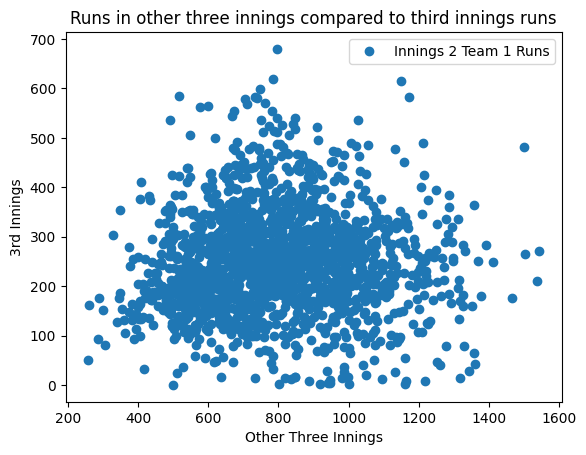

In [59]:
#Start by creating that songle scatterplot by itself and well labelled - to investigate, is there a relationship between runs made in other three ininngs (x) and runs made in 3rd innings innings (y)

df_thirdinnings.plot(x = 'Total Other Runs', y='Innings 2 Team 1 Runs',style='o') # The style option creates a scatterplot; without it, we only have lines.
plt.title('Runs in other three innings compared to third innings runs')
plt.xlabel('Other Three Innings')
plt.ylabel('3rd Innings')
plt.show()

Doesn't look like there is a relationship, as we hypothesised

In [60]:
# Reshape the variables into NumPy arrays and put them into separate objects.

X3 = df_thirdinnings['Total Other Runs'].values.reshape(-1,1)
Y3 = df_thirdinnings['Innings 2 Team 1 Runs'].values.reshape(-1,1)

In [61]:
# Split data into a training set and a test set.

X3_train, X3_test, Y3_train, Y3_test = train_test_split(X3, Y3, test_size=0.3, random_state=0)

In [62]:
# Create a regression object.

regression_3rd = LinearRegression()  # This is the regression object, which will be fit onto the training set.

In [63]:
# Fit the regression object onto the training set.
#' So we have given them the training data - 70% of our dataset - and it can now make predictions in our test data - the other 30%

regression_3rd.fit(X3_train, Y3_train)

LinearRegression()

In [64]:
# Predict the values of y using X.

Y_3rd_predicted = regression_3rd.predict(X3_test)

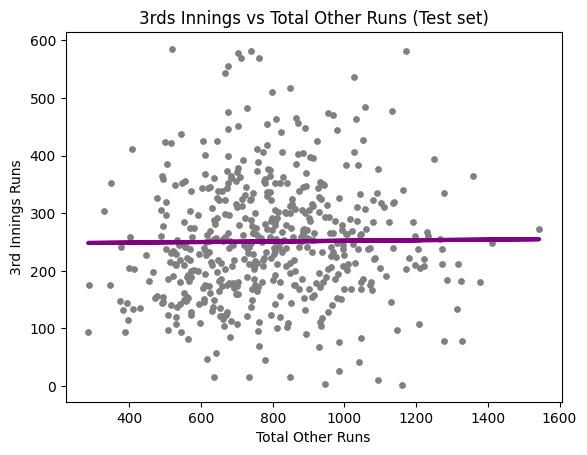

In [66]:
# Create a plot that shows the regression line from the model on the test set.

plot_test = plt
plot_test.scatter(X3_test, Y3_test, color='gray', s = 15)
plot_test.plot(X3_test, Y_3rd_predicted, color='purple', linewidth =3)
plot_test.title('3rds Innings vs Total Other Runs (Test set)')
plot_test.xlabel('Total Other Runs')
plot_test.ylabel('3rd Innings Runs')
plot_test.show()

REALLY doesn't look like a relationship, but let's run the numbers to see

In [68]:
# Create objects that contain the model summary statistics.

rmse_3rd = mean_squared_error(Y3_test, Y_3rd_predicted) # This is the mean squared error
r2_3rd = r2_score(Y3_test, Y_3rd_predicted) # This is the R2 score.

In [69]:
# Print the model summary statistics. This is where you evaluate the performance of the model.

print('Slope:' ,regression.coef_)
print('Mean squared error: ', rmse_3rd)
print('R2 score: ', r2_3rd)

Slope: [[-0.30129131]]
Mean squared error:  10968.318404592665
R2 score:  0.0011073384274774556


So, there's barely a slope, the means squared error is huge and the R2 score is tiny!

In [71]:
# Create a dataframe comparing the actual and predicted values of y.

data_3rd = pd.DataFrame({'Actual': Y3_test.flatten(), 'Predicted': Y_3rd_predicted.flatten()})
data_3rd.head(30)

,Actual,Predicted
0,107.0,253.125577
1,179.0,250.421163
2,271.0,252.003089
3,225.0,251.846462
4,350.0,251.726382
5,277.0,250.687428
6,362.0,250.515139
7,359.0,250.885821
8,141.0,251.862125
9,425.0,251.637627


#Commentary

These numbers really aren't very close at all.

Even from cursory look it's apparent there is no relationship - demonstrating my hypothesis.

#6. Thoughts on data bias

We can be confident that there is no bias in:
Collection - this is widely available, public data
Sample - this is almost evrry match ever played
Exclusion - we have excluded only matches where it makes no sense to look at them i.e. when there is no third innings score

I don't believe there can be measurement bias - we're using a well-known system to test for a simple relationship.

There could be biased presentation. We have about 125 years of resuilts to look at, the current game might behave unrecognisably from the older. (And that is somethign I have already identified I want to look at). Historic "noise" might be hiding current trends.